### Run this notebook online

[![Open in Colab](https://img.shields.io/badge/Open_in-Colab-F9AB00?logo=googlecolab&logoColor=F9AB00)](https://colab.research.google.com/github/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/blob/main/notebooks/CIFAR10%20DiT%20mini.ipynb)
[![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://www.kaggle.com/kernels/welcome?src=https%3A%2F%2Fgithub.com%2Fhosein-fanai%2FContinual-Learning-with-Diffusion-Vision-Transformers%2Fblob%2Fmain%2Fnotebooks%2FCIFAR10%2520DiT%2520mini.ipynb)
[![Launch Binder](https://img.shields.io/badge/launch-binder-F5793A?logo=jupyter&logoColor=white)](https://mybinder.org/v2/gh/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/main?urlpath=lab%2Ftree%2Fnotebooks%2FCIFAR10%20DiT%20mini.ipynb)

- **Google Colab:** open the notebook, select a GPU for training under **Runtime > Change runtime type**, then choose **Run all**.
- **Kaggle:** sign in and import the notebook, enable **Internet**, select a **GPU** accelerator for training, then **Run all**.
- **Binder:** opens a temporary CPU JupyterLab session. Use it to inspect the notebook or run small checks; full training needs more resources.
- **[Studio Lab](https://studiolab.sagemaker.aws/import/github/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/blob/main/notebooks/CIFAR10%20DiT%20mini.ipynb) (existing accounts only):** start a runtime, copy the notebook to your project, select a Python **3.11–3.13** kernel, and set `RUNTIME = "studiolab"` in the first code cell before **Run all**. For CPU, also set `CUDA = False`.

The **first code cell** finds or downloads the repository and prepares TensorFlow **2.20** / Keras **3.11.2** before project imports. If setup requests a restart, restart the kernel and run all again. For another hosted Jupyter service, set `RUNTIME = "hosted"` (`CUDA = False` for CPU or compatible provider-managed CUDA). Locally, select the project TensorFlow kernel.

Launch links open the published GitHub `main` version; publish this notebook and its setup files together before using them. For a notebook that has not been published, upload its `.ipynb` file to Colab or Kaggle instead. GPU availability depends on the provider. Save checkpoints and results before a temporary session ends.

See the [hosted runtime guide](https://github.com/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/blob/main/notebooks/thesis/README.md#hosted-runtimes) for setup and import details.


In [1]:
# Shared setup: use the local initializer when available, otherwise download it.
from pathlib import Path
from urllib.request import urlopen


CHECKOUT_NAME = "Continual-Learning-with-Diffusion-Vision-Transformers"
REPOSITORY = f"https://github.com/hosein-fanai/{CHECKOUT_NAME}.git"
REVISION = "main"
RUNTIME = "auto"  # Use "hosted" for another online service, or "local" to verify only.
CUDA = None  # False: CPU or managed CUDA; True: retain CUDA pip dependencies.

_locations = (Path.cwd(), *Path.cwd().parents, Path.cwd() / CHECKOUT_NAME,
              Path("/kaggle/working") / CHECKOUT_NAME, Path("/content") / CHECKOUT_NAME)
_initializer = next((path / "notebooks" / "init.py" for path in _locations
                     if (path / "notebooks" / "init.py").is_file()), None)
_url = f"https://raw.githubusercontent.com/hosein-fanai/{CHECKOUT_NAME}/{REVISION}/notebooks/init.py"
_setup = {"__name__": "notebook_setup", "__file__": str(_initializer or _url)}
with (_initializer.open("rb") if _initializer else urlopen(_url, timeout=30)) as _file:
    exec(compile(_file.read(), _setup["__file__"], "exec"), _setup)
ROOT, RUNTIME_PACKAGES = _setup["prepare_notebook"](
    checkout_name=CHECKOUT_NAME, 
    repository=REPOSITORY, 
    revision=REVISION,
    runtime=RUNTIME, 
    cuda=CUDA
)


Repository ready: /workspace (runtime: local)
Runtime packages ready: Python 3.11.13, TensorFlow 2.20.0, Keras 3.11.2


In [2]:
import init

In [3]:
import tensorflow as tf


def get_dataset(x, y, batch_size=128, shuffle_buffer=10_000, drop_remainder=True):
    """Scale image bytes to diffusion space and batch aligned labels.

    The affine transform does not clip values. No prefetching, repetition, validation
    split, or deterministic shuffle seed is added. Labels remain aligned with images
    while shuffling.

    Args:
        x (np.ndarray): Image values nominally in [0, 255]. Expected NHW grayscale
            input; a singleton channel is appended unconditionally.
        y (np.ndarray): Labels with the same leading length as x. One is added to
            reserve zero for classifier-free null conditioning.
        batch_size (int): Number of examples in each dataset batch. Defaults to ``128``.
        shuffle_buffer (int | None): None preserves input order; a positive integer
            enables shuffling without an explicit operation seed. TensorFlow global
            seeding can still control this randomness. Defaults to ``10000``.
        drop_remainder (bool): True discards an incomplete final batch; False retains
            it. Defaults to ``True``.

    Returns:
        tf.data.Dataset: Finite (images, labels) batches, with float32 image values
        transformed as 2*x/255-1 and the configured remainder policy.
    """

    x = x.astype("float32") / 255.0
    x = (x * 2.0) - 1.0
    # x = x[..., None]

    y = y.reshape((-1,))

    dataset = tf.data.Dataset.from_tensor_slices((x, y))
    # A supplied buffer enables random shuffling; None keeps input order.
    if shuffle_buffer is not None:
        dataset = dataset.shuffle(shuffle_buffer)
    dataset = dataset.batch(batch_size, drop_remainder=drop_remainder)

    return dataset

2026-09-18 01:57:55.812630: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
epochs = 50

In [5]:
from tensorflow.keras import datasets


(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

trainset = get_dataset(x_train, y_train)
valset = get_dataset(x_test, y_test, shuffle_buffer=None, drop_remainder=False)

2026-09-18 01:58:24.211529: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1789696704.211593   76477 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4055 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060, pci bus id: 0000:01:00.0, compute capability: 7.5


In [6]:
from diffusion.models.transformer.diffusion_transformer import DiffusionTransformer
from diffusion.models.wrapper.diffusion_model import DiffusionModel


vit = DiffusionTransformer(
    image_size=32, 
    channels=3, 
    dim=64, 
    depth=4
)
model = DiffusionModel(network=vit)

vit.summary()

Model: "diffusion_transformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ depth_0_patch_embedder          │ (None, 256, 64)        │           832 │
│ (PatchEmbedding)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_0_time_embedder           │ (None, 64)             │        64,000 │
│ (ConditionEmbedding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_0_label_embedder          │ (None, 64)             │           704 │
│ (ConditionEmbedding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_0_time_label_merger (Add) │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_1_encoder_block           │ (None, 256, 64)        │        74,694 │
│ (VisionTransformerBlock)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_2_encoder_block           │ (None, 256, 64)        │        74,694 │
│ (VisionTransformerBlock)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_3_encoder_block           │ (None, 256, 64)        │        74,694 │
│ (VisionTransformerBlock)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_4_encoder_block           │ (None, 256, 64)        │        74,694 │
│ (VisionTransformerBlock)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ unpatchifier (Functional)       │ (None, 32, 32, 3)      │         9,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 373,412 (1.42 MB)

 Trainable params: 309,388 (1.18 MB)

 Non-trainable params: 64,024 (250.19 KB)

In [7]:
from tensorflow.keras import optimizers


lr_schedule = optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3, # 5e-3
    decay_steps=epochs * len(trainset)
)

model.compile(
    optimizer=optimizers.Adam(lr_schedule), 
    loss="mse"
)

In [8]:
from tensorflow.keras import callbacks

from diffusion import ImageGenerator
from common.callbacks.lr_logger import LrLogger


callbacks_list = [
    LrLogger(), 
    callbacks.ProgbarLogger(), 
    ImageGenerator()
]

Epoch 1/50


2026-09-18 01:58:44.611108: I external/local_xla/xla/service/service.cc:163] XLA service 0x7c4054002cf0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-09-18 01:58:44.611145: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2060, Compute Capability 7.5
2026-09-18 01:58:45.009875: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-09-18 01:58:47.150979: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92600
I0000 00:00:1789696736.231223   76541 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


390/390 ━━━━━━━━━━━━━━━━━━━━ 66s 105ms/step - noise_loss: 0.0974 - val_image_loss: 27.0764 - val_loss: 0.7551 - val_noise_loss: 0.7551 - learning_rate: 9.9901e-04


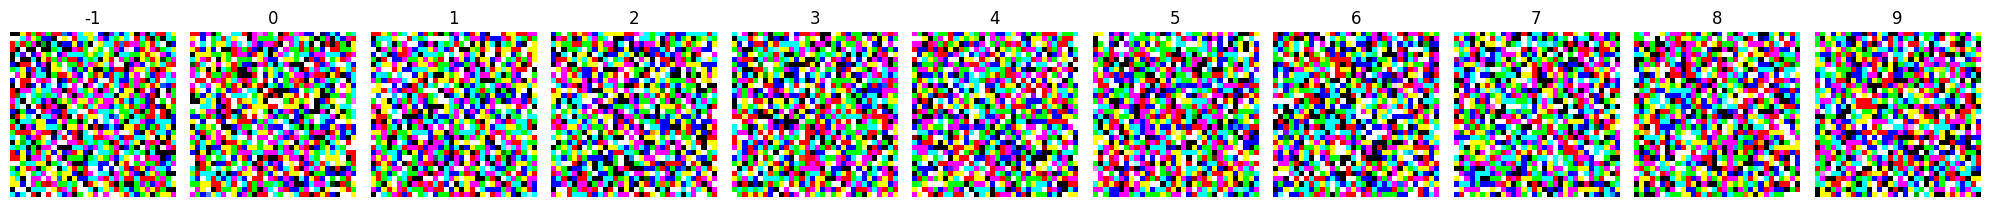

Epoch 2/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 31s 80ms/step - noise_loss: 0.0378 - val_image_loss: 11.4167 - val_loss: 0.3791 - val_noise_loss: 0.3791 - learning_rate: 9.9606e-04


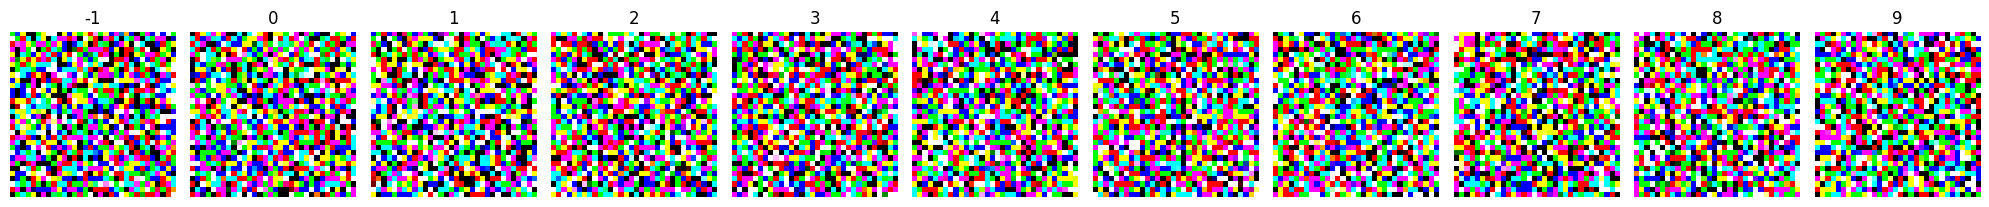

Epoch 3/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 31s 80ms/step - noise_loss: 0.0355 - val_image_loss: 3.5036 - val_loss: 0.1610 - val_noise_loss: 0.1610 - learning_rate: 9.9114e-04


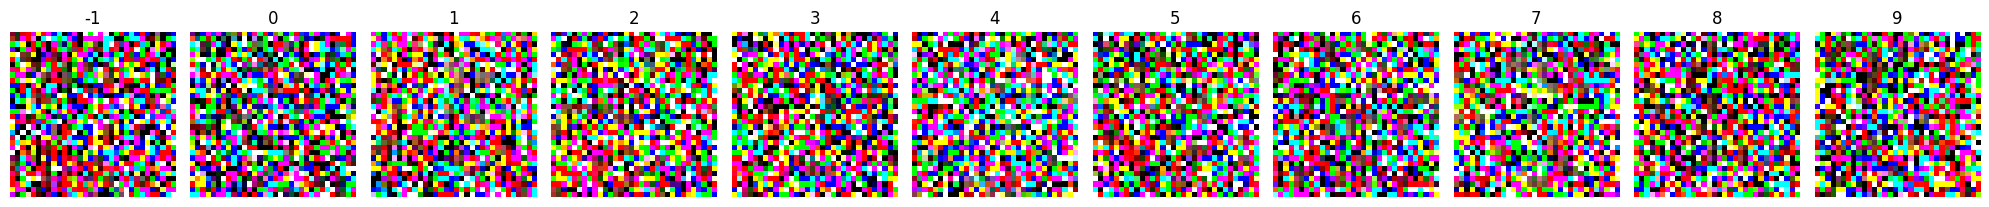

Epoch 4/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 31s 79ms/step - noise_loss: 0.0342 - val_image_loss: 0.9977 - val_loss: 0.0848 - val_noise_loss: 0.0848 - learning_rate: 9.8429e-04


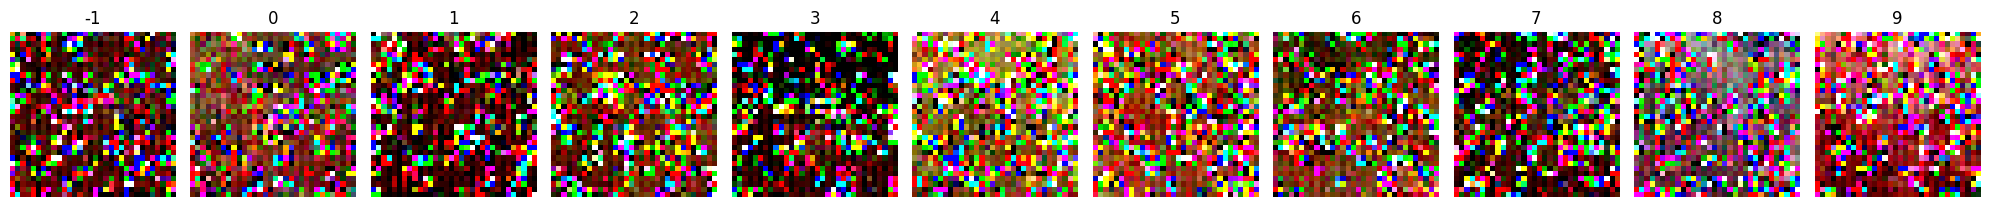

Epoch 5/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 31s 79ms/step - noise_loss: 0.0337 - val_image_loss: 0.4276 - val_loss: 0.0583 - val_noise_loss: 0.0583 - learning_rate: 9.7553e-04


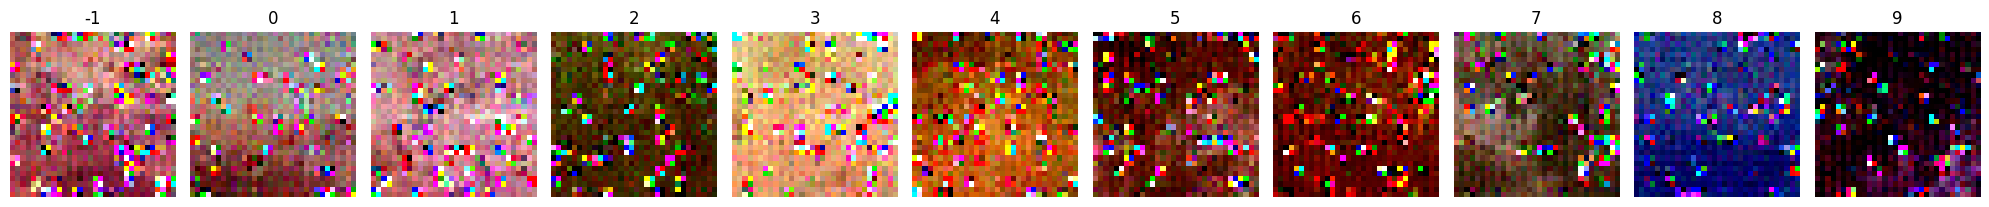

Epoch 6/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 31s 80ms/step - noise_loss: 0.0331 - val_image_loss: 0.2177 - val_loss: 0.0456 - val_noise_loss: 0.0456 - learning_rate: 9.6489e-04


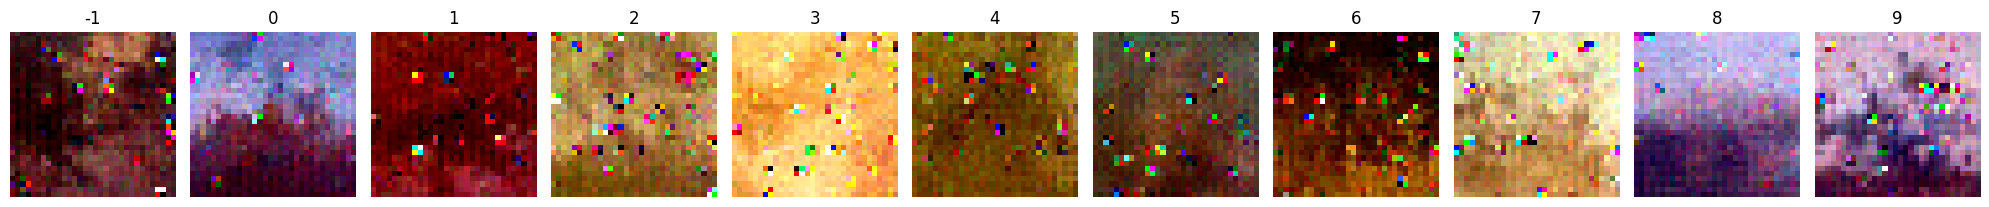

Epoch 7/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 32s 82ms/step - noise_loss: 0.0328 - val_image_loss: 0.1581 - val_loss: 0.0389 - val_noise_loss: 0.0389 - learning_rate: 9.5241e-04


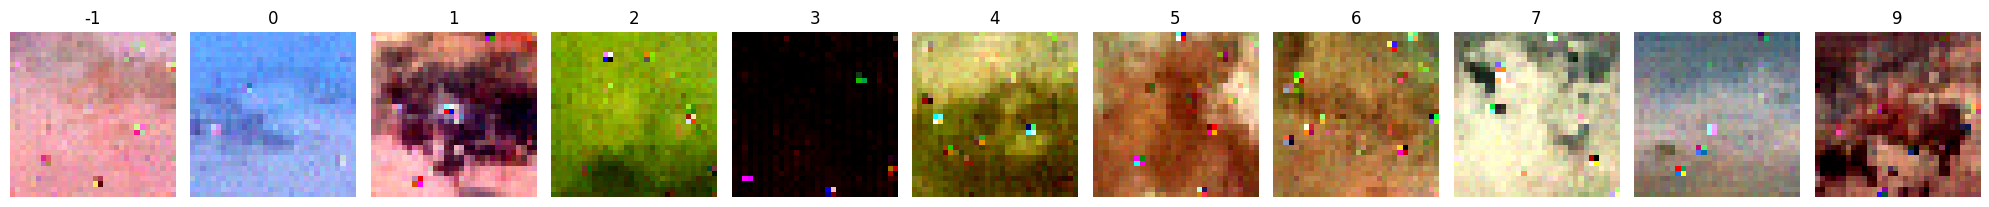

Epoch 8/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 34s 86ms/step - noise_loss: 0.0322 - val_image_loss: 0.1231 - val_loss: 0.0364 - val_noise_loss: 0.0364 - learning_rate: 9.3815e-04


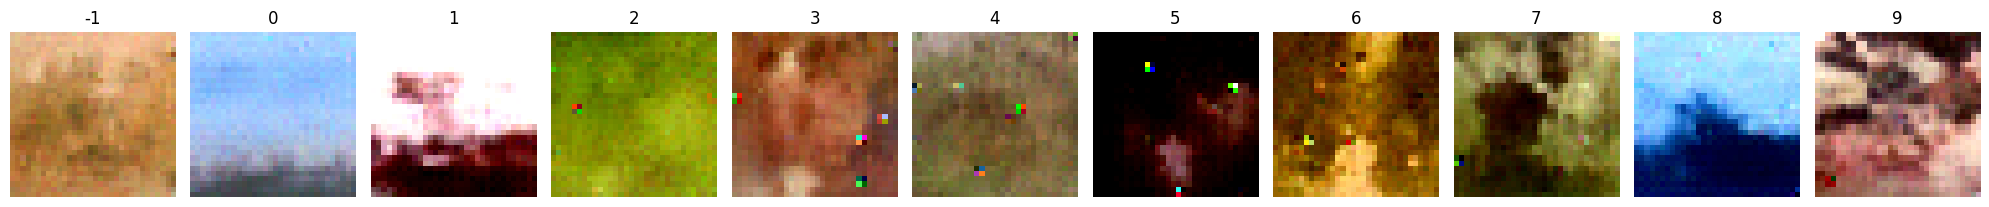

Epoch 9/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 34s 86ms/step - noise_loss: 0.0320 - val_image_loss: 0.1058 - val_loss: 0.0348 - val_noise_loss: 0.0348 - learning_rate: 9.2216e-04


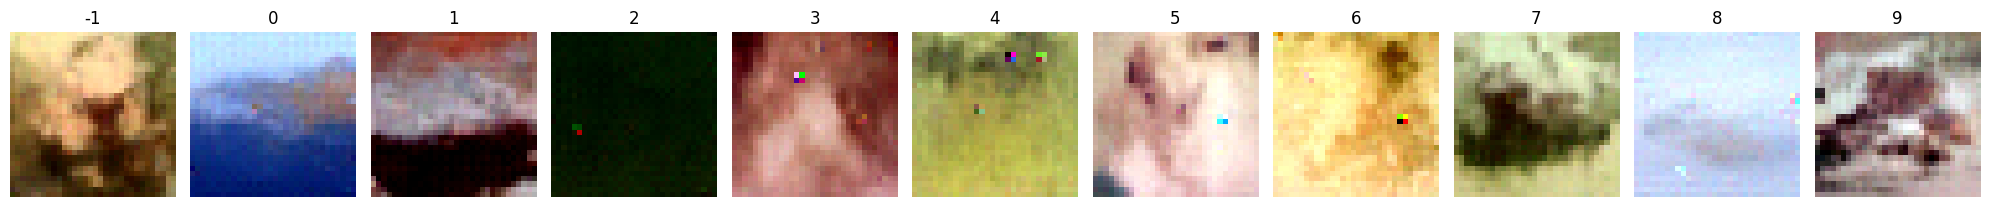

Epoch 10/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 89ms/step - noise_loss: 0.0320 - val_image_loss: 0.0939 - val_loss: 0.0349 - val_noise_loss: 0.0349 - learning_rate: 9.0451e-04


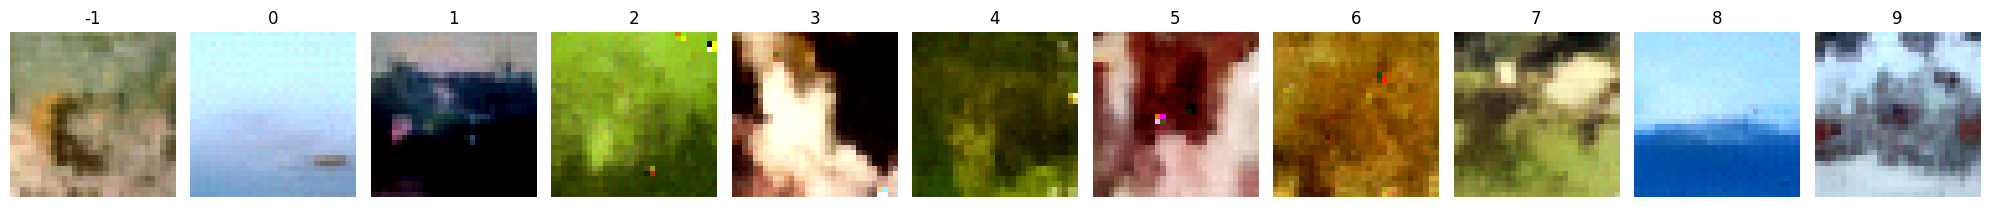

Epoch 11/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 33s 83ms/step - noise_loss: 0.0316 - val_image_loss: 0.0940 - val_loss: 0.0334 - val_noise_loss: 0.0334 - learning_rate: 8.8526e-04


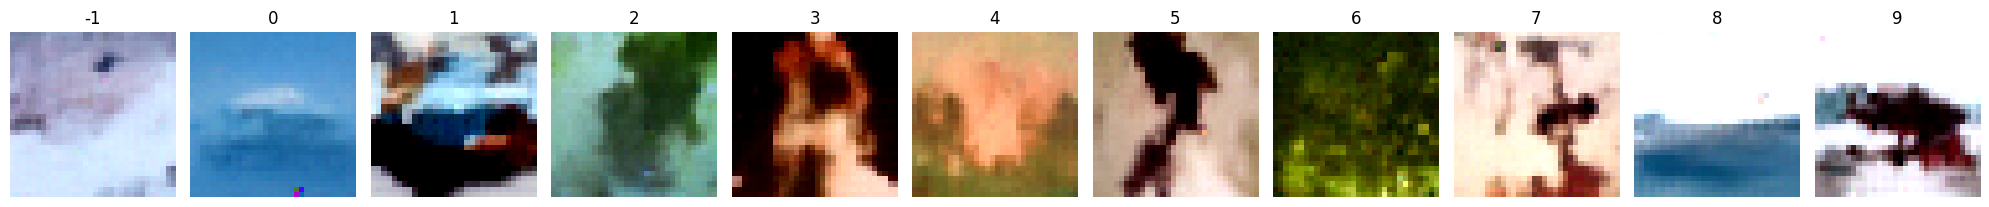

Epoch 12/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 33s 83ms/step - noise_loss: 0.0317 - val_image_loss: 0.0914 - val_loss: 0.0329 - val_noise_loss: 0.0329 - learning_rate: 8.6448e-04


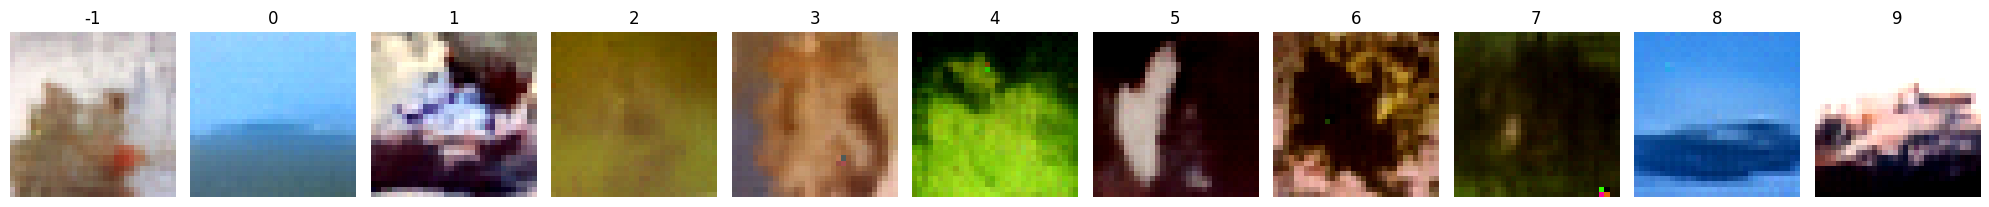

Epoch 13/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 35s 90ms/step - noise_loss: 0.0317 - val_image_loss: 0.0902 - val_loss: 0.0333 - val_noise_loss: 0.0333 - learning_rate: 8.4227e-04


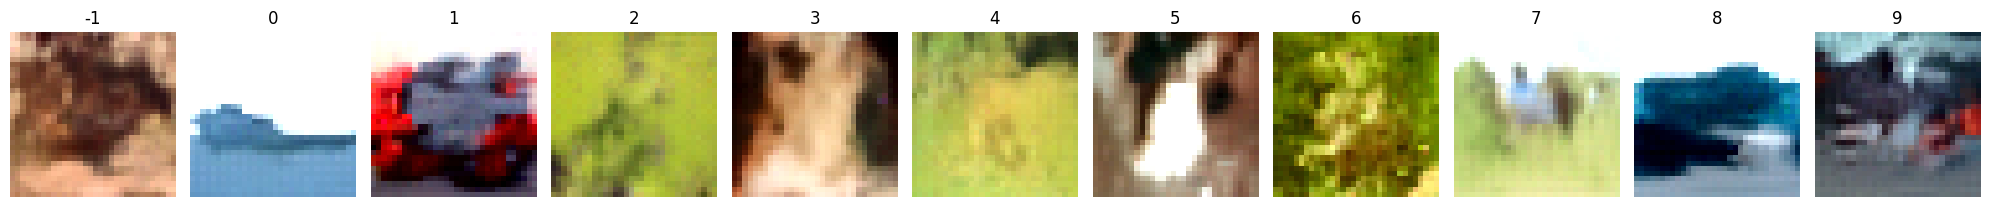

Epoch 14/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 34s 87ms/step - noise_loss: 0.0312 - val_image_loss: 0.0904 - val_loss: 0.0330 - val_noise_loss: 0.0330 - learning_rate: 8.1871e-04


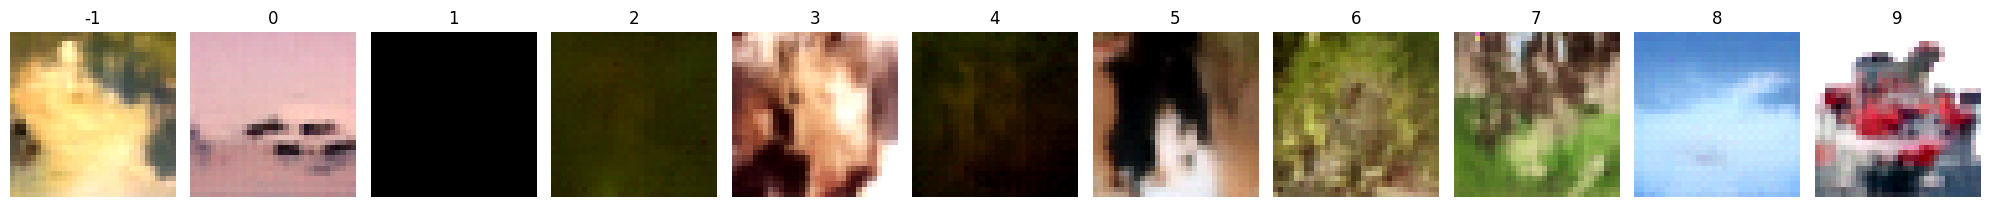

Epoch 15/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 33s 85ms/step - noise_loss: 0.0314 - val_image_loss: 0.0916 - val_loss: 0.0324 - val_noise_loss: 0.0324 - learning_rate: 7.9389e-04


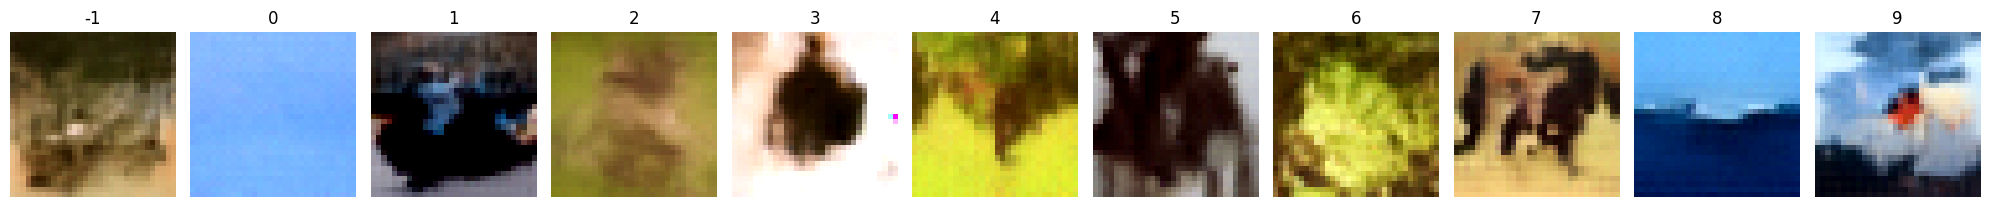

Epoch 16/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 33s 85ms/step - noise_loss: 0.0314 - val_image_loss: 0.0881 - val_loss: 0.0325 - val_noise_loss: 0.0325 - learning_rate: 7.6791e-04


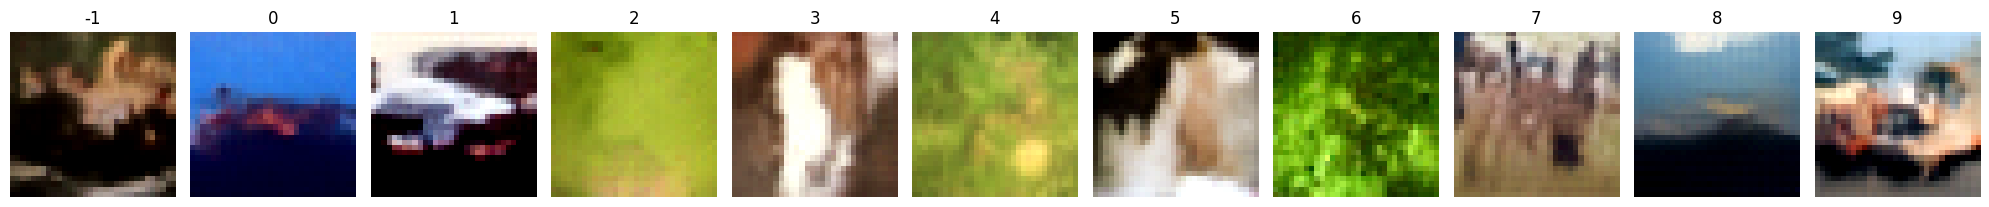

Epoch 17/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 33s 83ms/step - noise_loss: 0.0311 - val_image_loss: 0.0876 - val_loss: 0.0327 - val_noise_loss: 0.0327 - learning_rate: 7.4088e-04


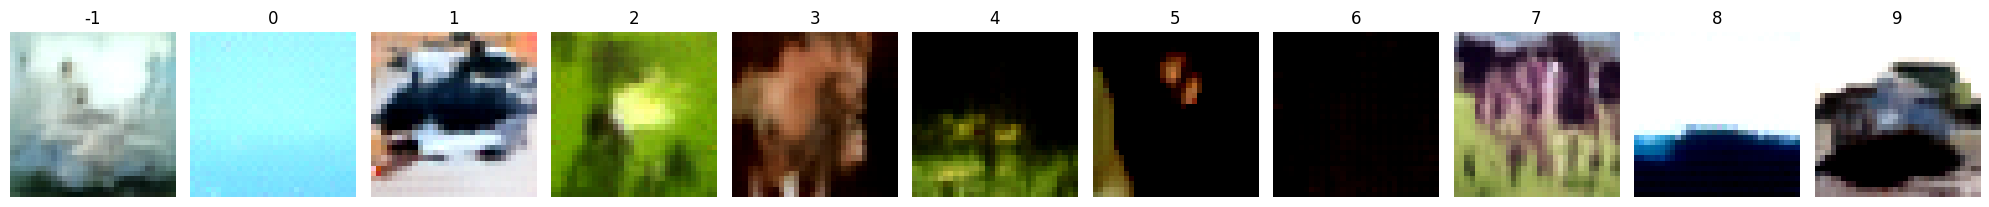

Epoch 18/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 32s 81ms/step - noise_loss: 0.0309 - val_image_loss: 0.0874 - val_loss: 0.0326 - val_noise_loss: 0.0326 - learning_rate: 7.1289e-04


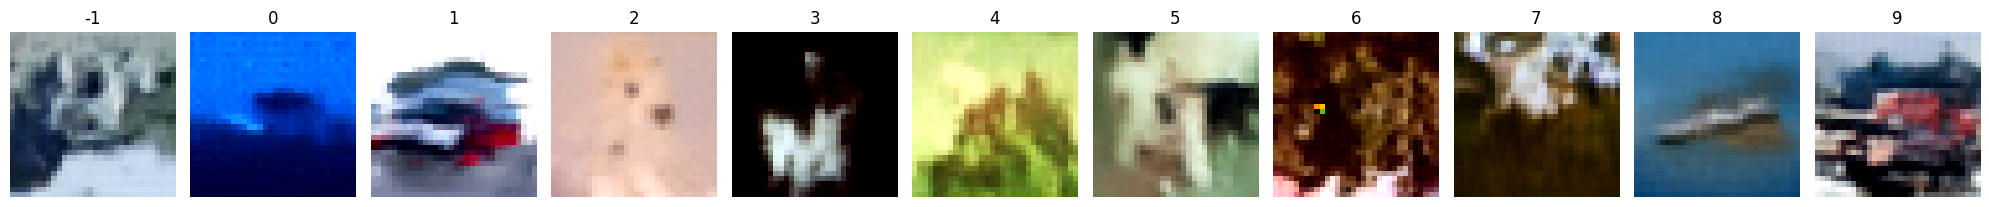

Epoch 19/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 32s 81ms/step - noise_loss: 0.0307 - val_image_loss: 0.0853 - val_loss: 0.0328 - val_noise_loss: 0.0328 - learning_rate: 6.8406e-04


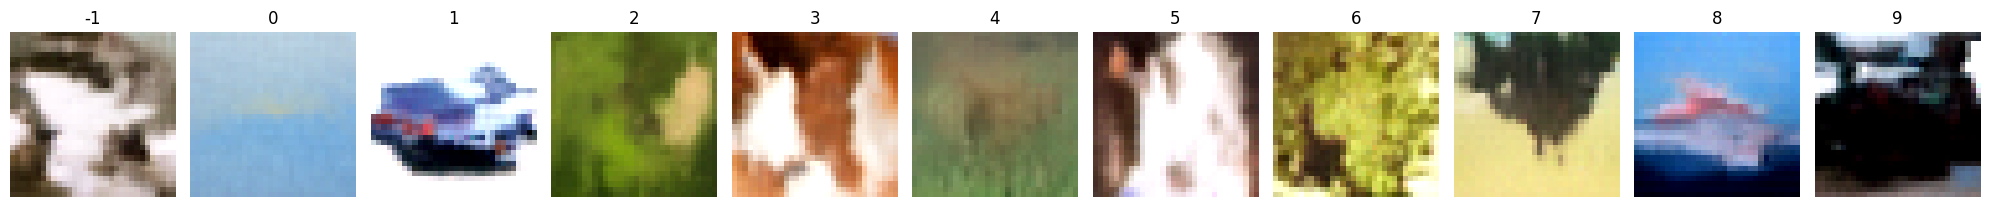

Epoch 20/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 33s 85ms/step - noise_loss: 0.0310 - val_image_loss: 0.0867 - val_loss: 0.0320 - val_noise_loss: 0.0320 - learning_rate: 6.5451e-04


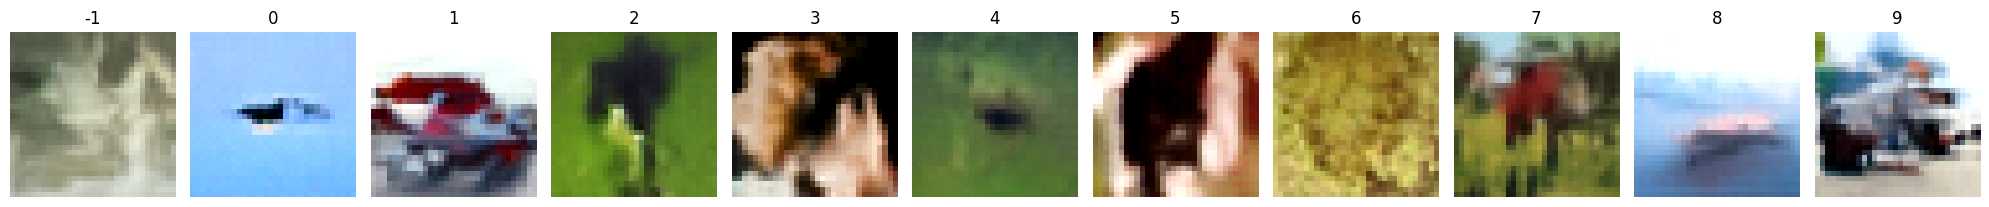

Epoch 21/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 34s 86ms/step - noise_loss: 0.0308 - val_image_loss: 0.0825 - val_loss: 0.0328 - val_noise_loss: 0.0328 - learning_rate: 6.2435e-04


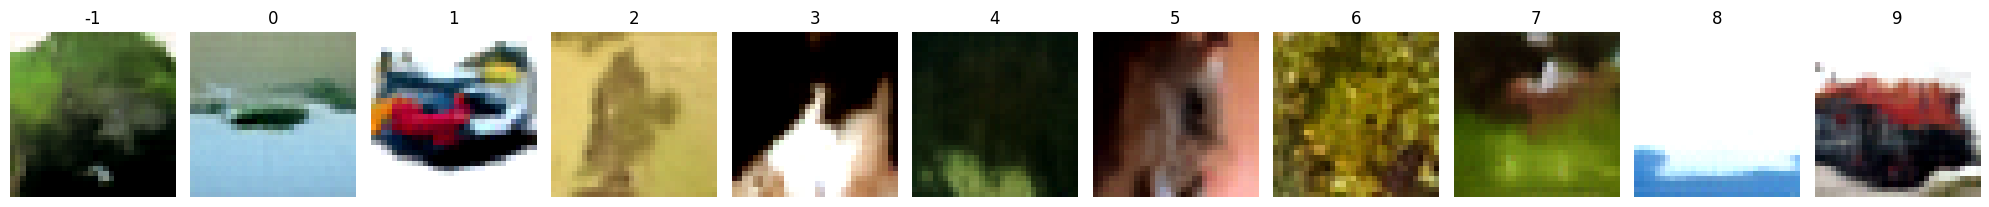

Epoch 22/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 34s 86ms/step - noise_loss: 0.0307 - val_image_loss: 0.0866 - val_loss: 0.0326 - val_noise_loss: 0.0326 - learning_rate: 5.9369e-04


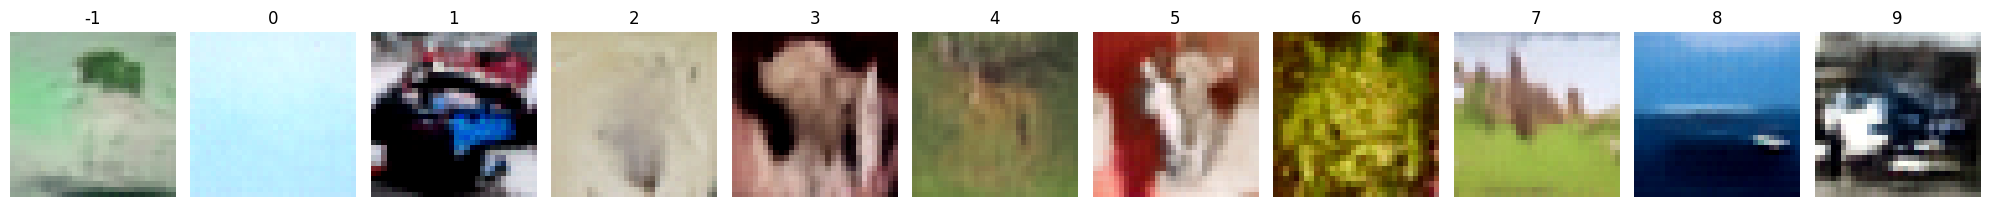

Epoch 23/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 34s 87ms/step - noise_loss: 0.0307 - val_image_loss: 0.0848 - val_loss: 0.0323 - val_noise_loss: 0.0323 - learning_rate: 5.6267e-04


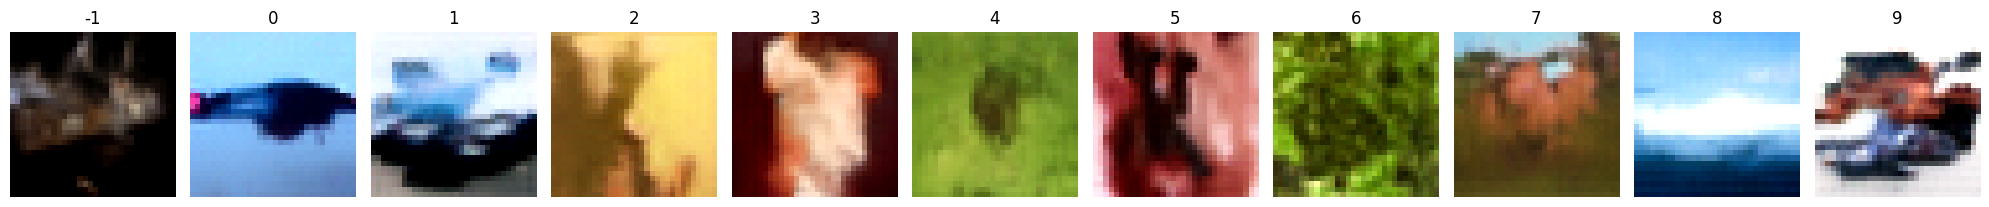

Epoch 24/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 32s 83ms/step - noise_loss: 0.0305 - val_image_loss: 0.0838 - val_loss: 0.0325 - val_noise_loss: 0.0325 - learning_rate: 5.3140e-04


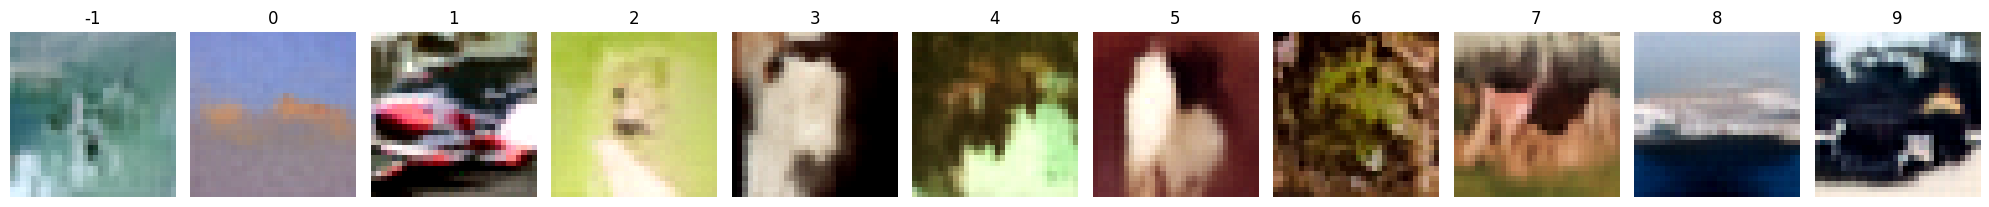

Epoch 25/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 33s 84ms/step - noise_loss: 0.0305 - val_image_loss: 0.0850 - val_loss: 0.0323 - val_noise_loss: 0.0323 - learning_rate: 5.0000e-04


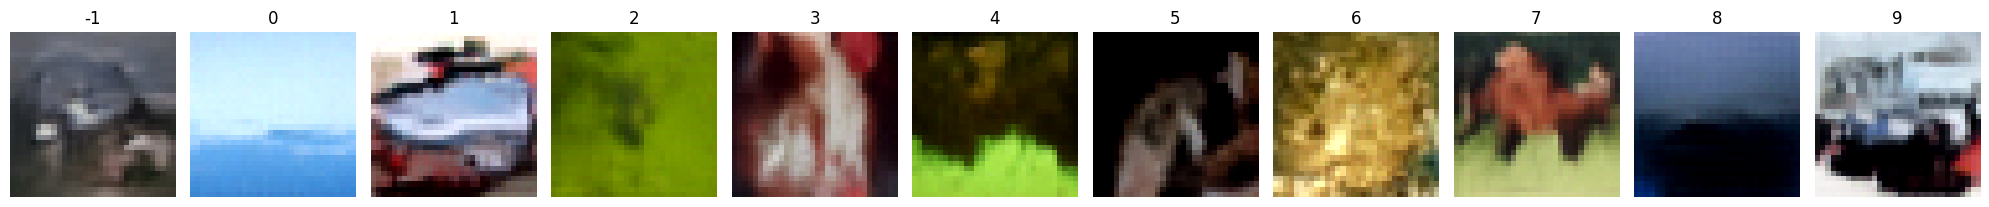

Epoch 26/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 34s 86ms/step - noise_loss: 0.0303 - val_image_loss: 0.0878 - val_loss: 0.0324 - val_noise_loss: 0.0324 - learning_rate: 4.6860e-04


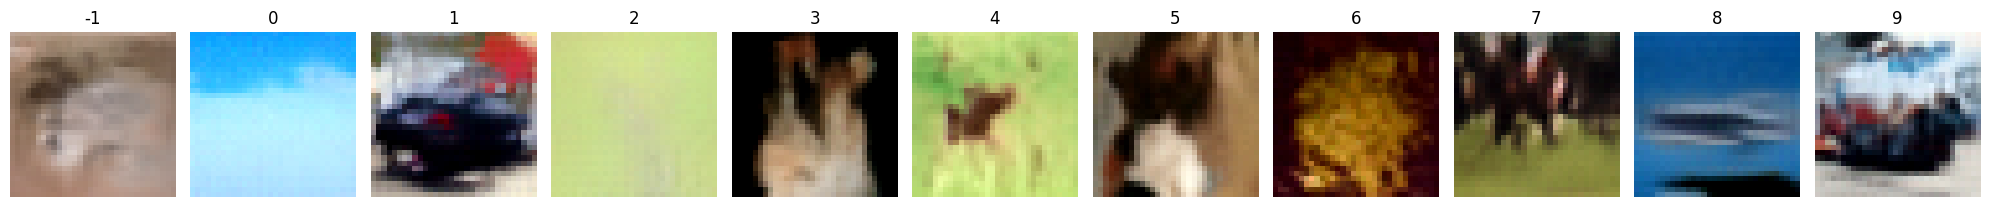

Epoch 27/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 33s 83ms/step - noise_loss: 0.0305 - val_image_loss: 0.0843 - val_loss: 0.0325 - val_noise_loss: 0.0325 - learning_rate: 4.3733e-04


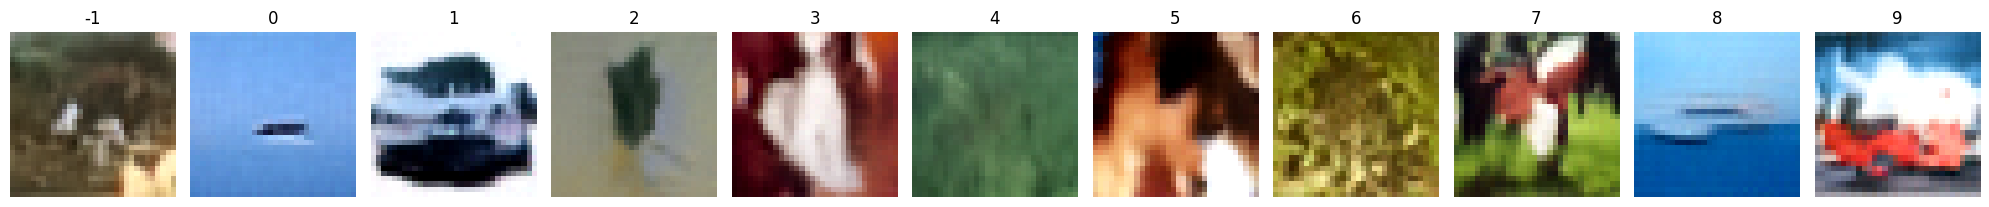

Epoch 28/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 32s 82ms/step - noise_loss: 0.0304 - val_image_loss: 0.0829 - val_loss: 0.0328 - val_noise_loss: 0.0328 - learning_rate: 4.0631e-04


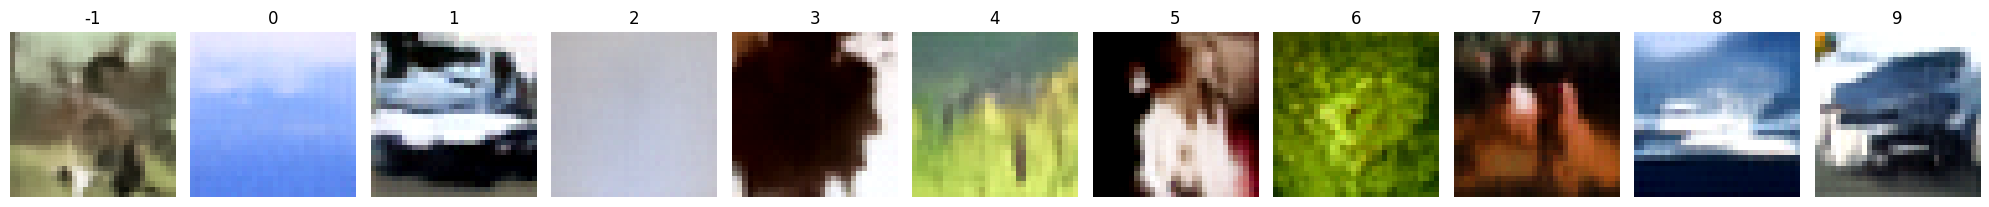

Epoch 29/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 32s 82ms/step - noise_loss: 0.0304 - val_image_loss: 0.0853 - val_loss: 0.0323 - val_noise_loss: 0.0323 - learning_rate: 3.7566e-04


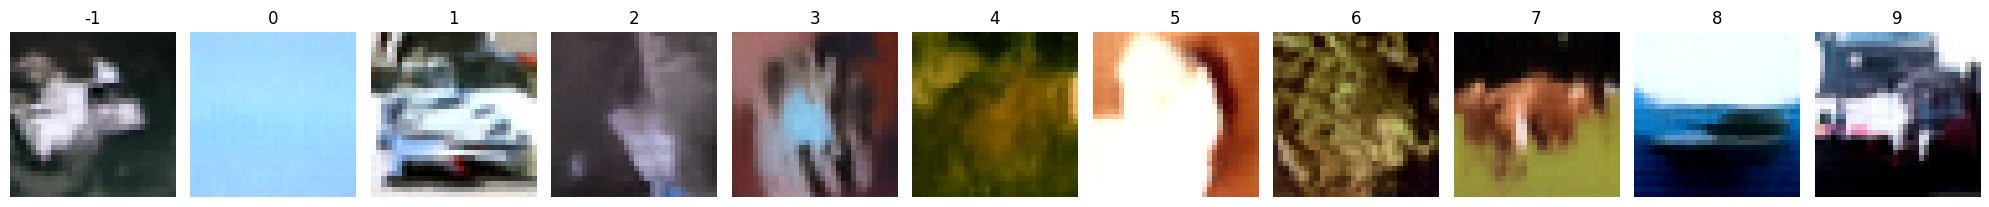

Epoch 30/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 32s 82ms/step - noise_loss: 0.0302 - val_image_loss: 0.0843 - val_loss: 0.0324 - val_noise_loss: 0.0324 - learning_rate: 3.4549e-04


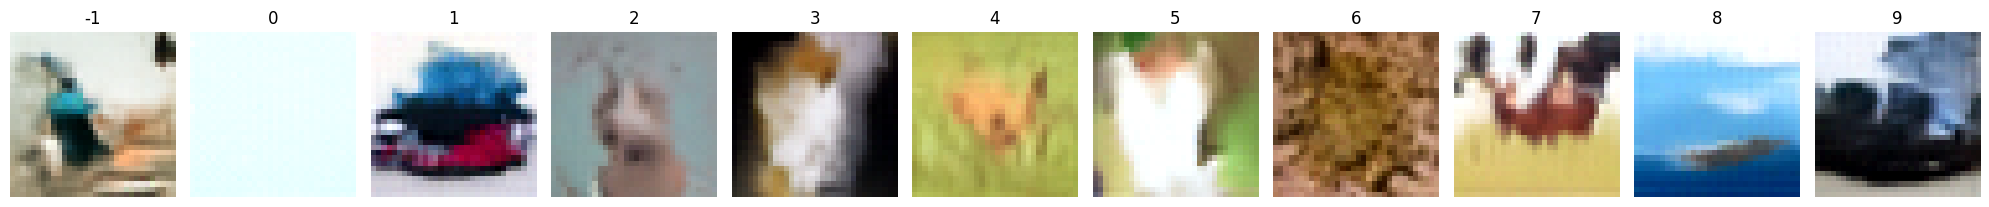

Epoch 31/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 32s 81ms/step - noise_loss: 0.0302 - val_image_loss: 0.0849 - val_loss: 0.0326 - val_noise_loss: 0.0326 - learning_rate: 3.1594e-04


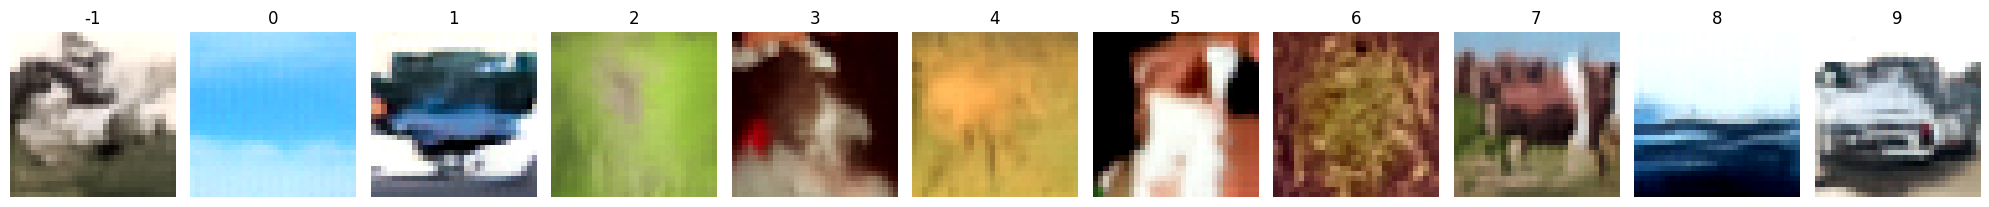

Epoch 32/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 32s 82ms/step - noise_loss: 0.0302 - val_image_loss: 0.0845 - val_loss: 0.0329 - val_noise_loss: 0.0329 - learning_rate: 2.8711e-04


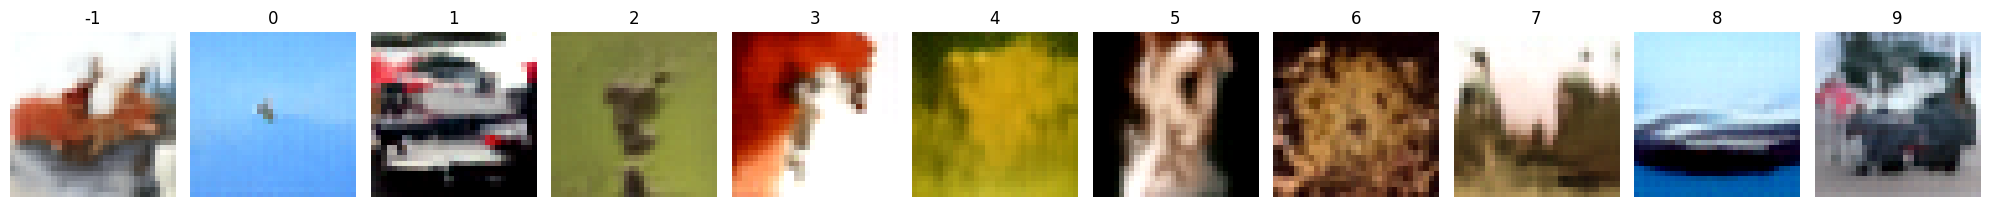

Epoch 33/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 33s 83ms/step - noise_loss: 0.0301 - val_image_loss: 0.0839 - val_loss: 0.0325 - val_noise_loss: 0.0325 - learning_rate: 2.5912e-04


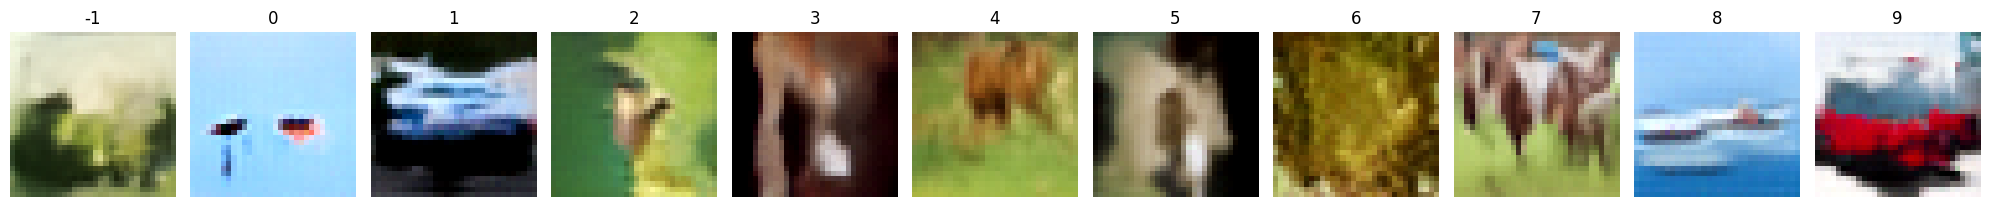

Epoch 34/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 32s 82ms/step - noise_loss: 0.0303 - val_image_loss: 0.0824 - val_loss: 0.0326 - val_noise_loss: 0.0326 - learning_rate: 2.3209e-04


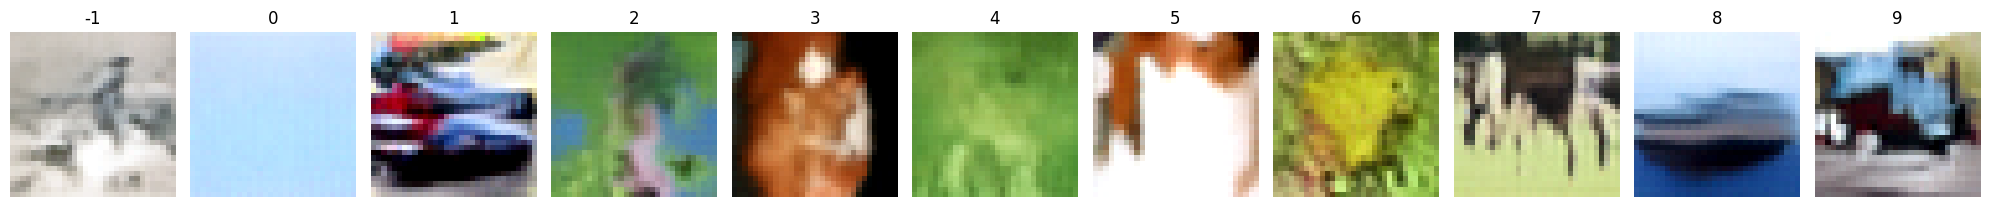

Epoch 35/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 33s 83ms/step - noise_loss: 0.0303 - val_image_loss: 0.0823 - val_loss: 0.0323 - val_noise_loss: 0.0323 - learning_rate: 2.0611e-04


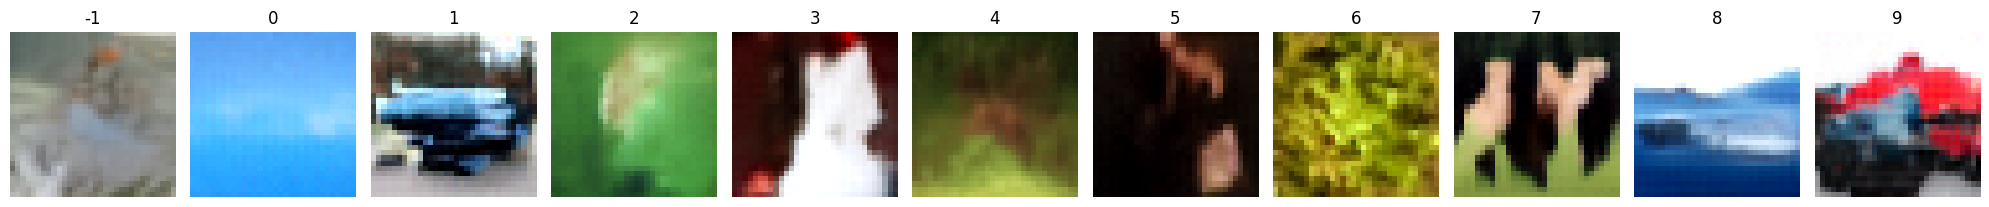

Epoch 36/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 32s 83ms/step - noise_loss: 0.0298 - val_image_loss: 0.0813 - val_loss: 0.0323 - val_noise_loss: 0.0323 - learning_rate: 1.8129e-04


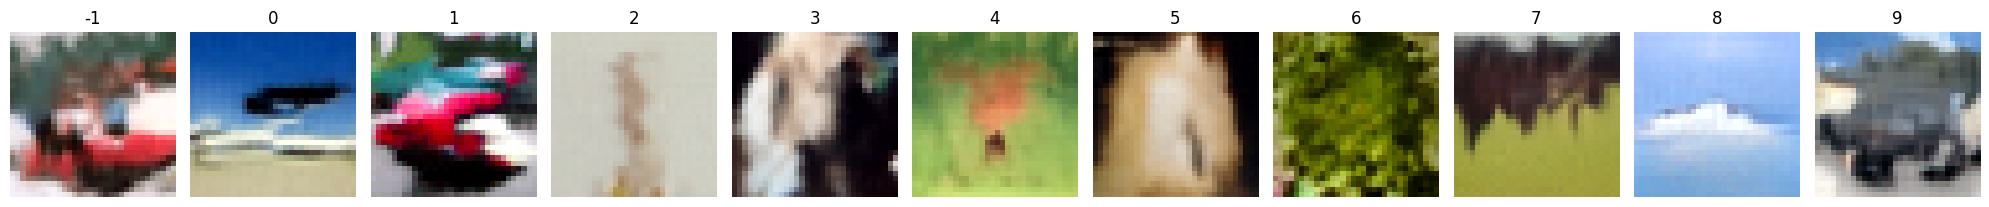

Epoch 37/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 32s 82ms/step - noise_loss: 0.0300 - val_image_loss: 0.0829 - val_loss: 0.0323 - val_noise_loss: 0.0323 - learning_rate: 1.5773e-04


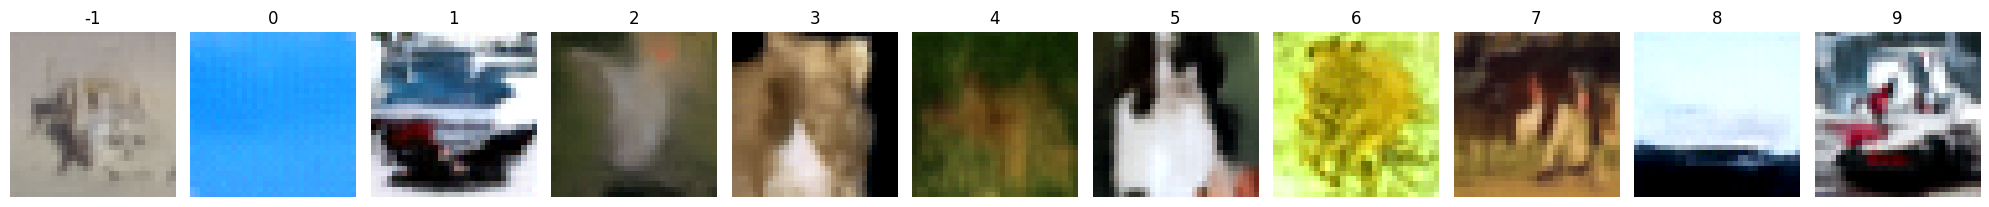

Epoch 38/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 32s 81ms/step - noise_loss: 0.0298 - val_image_loss: 0.0811 - val_loss: 0.0324 - val_noise_loss: 0.0324 - learning_rate: 1.3552e-04


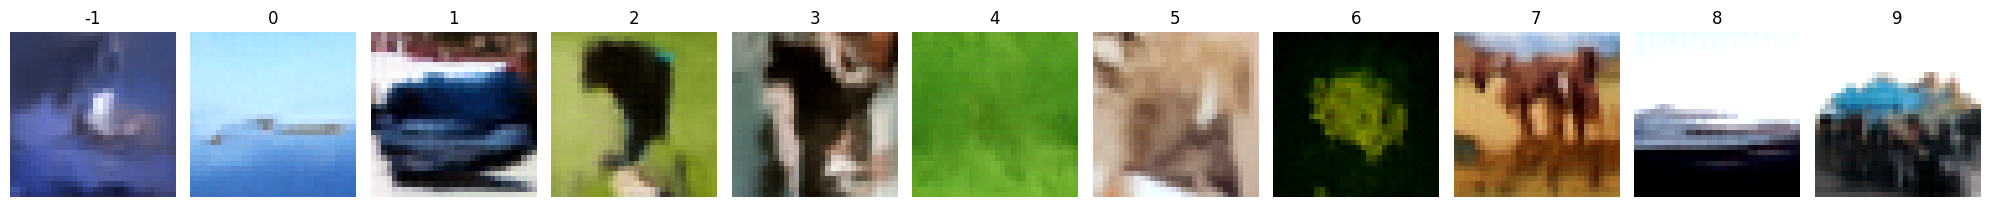

Epoch 39/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 32s 82ms/step - noise_loss: 0.0301 - val_image_loss: 0.0835 - val_loss: 0.0321 - val_noise_loss: 0.0321 - learning_rate: 1.1474e-04


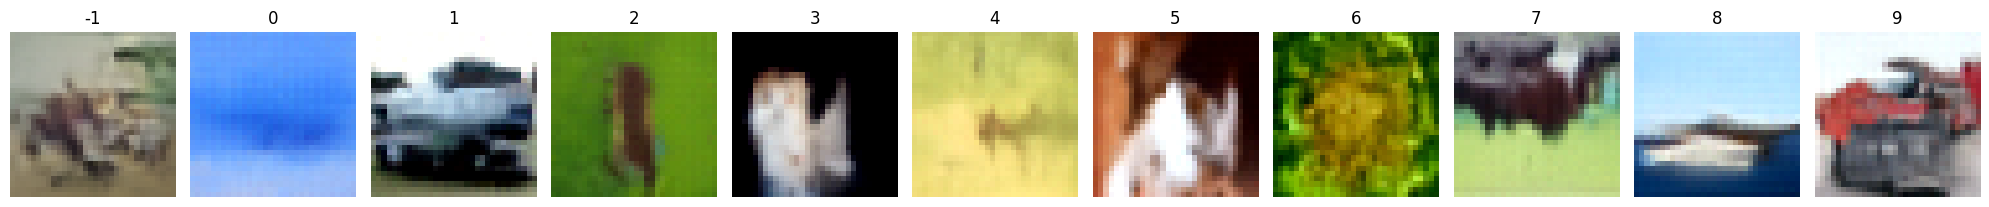

Epoch 40/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 33s 83ms/step - noise_loss: 0.0300 - val_image_loss: 0.0839 - val_loss: 0.0319 - val_noise_loss: 0.0319 - learning_rate: 9.5491e-05


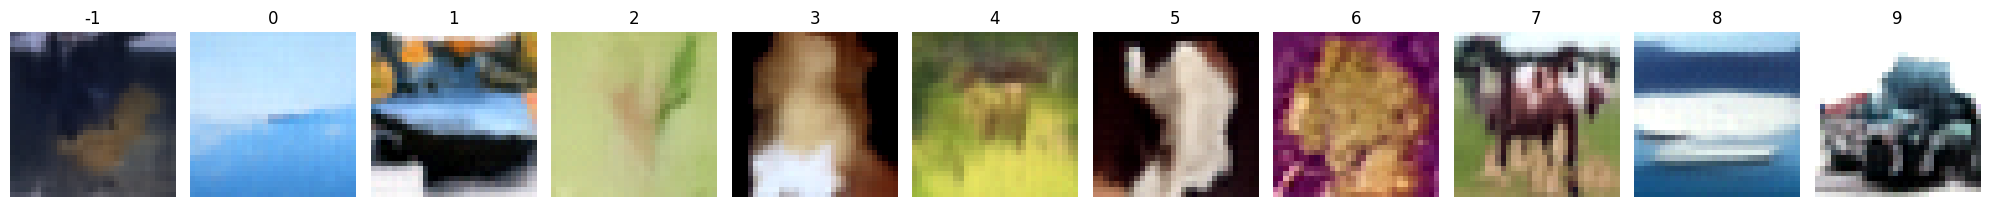

Epoch 41/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 33s 84ms/step - noise_loss: 0.0299 - val_image_loss: 0.0841 - val_loss: 0.0321 - val_noise_loss: 0.0321 - learning_rate: 7.7836e-05


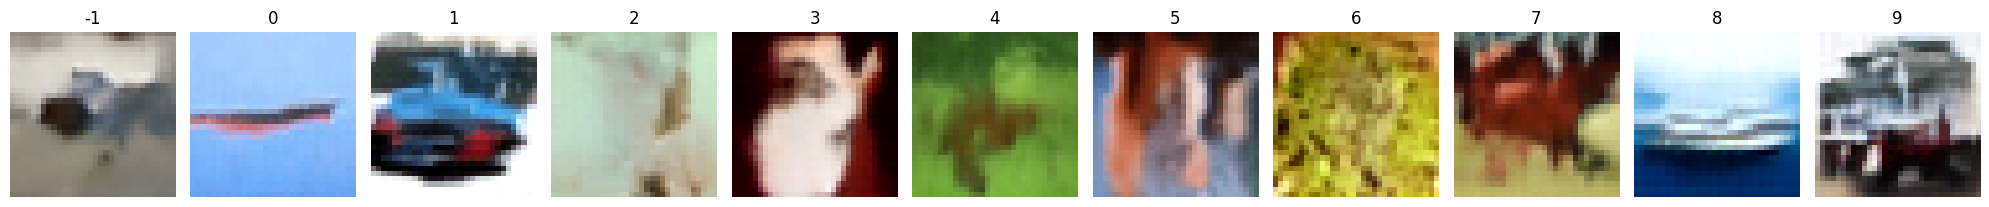

Epoch 42/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 33s 85ms/step - noise_loss: 0.0301 - val_image_loss: 0.0843 - val_loss: 0.0322 - val_noise_loss: 0.0322 - learning_rate: 6.1847e-05


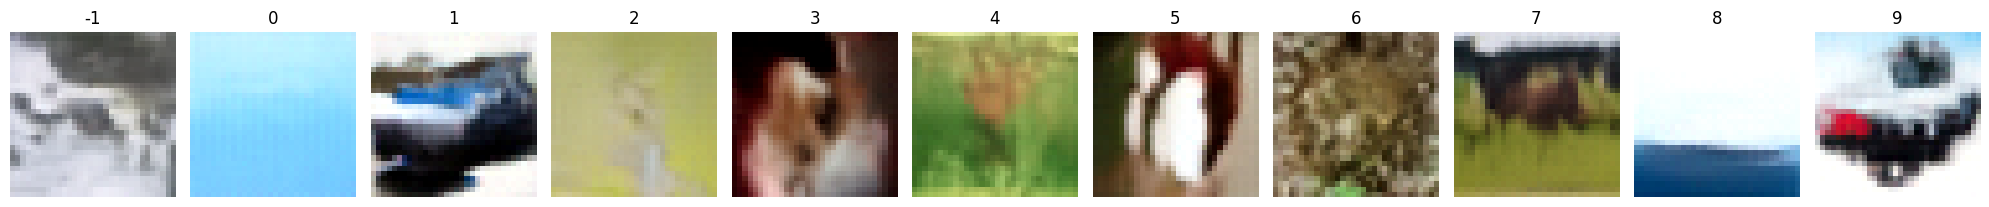

Epoch 43/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 33s 83ms/step - noise_loss: 0.0301 - val_image_loss: 0.0827 - val_loss: 0.0326 - val_noise_loss: 0.0326 - learning_rate: 4.7586e-05


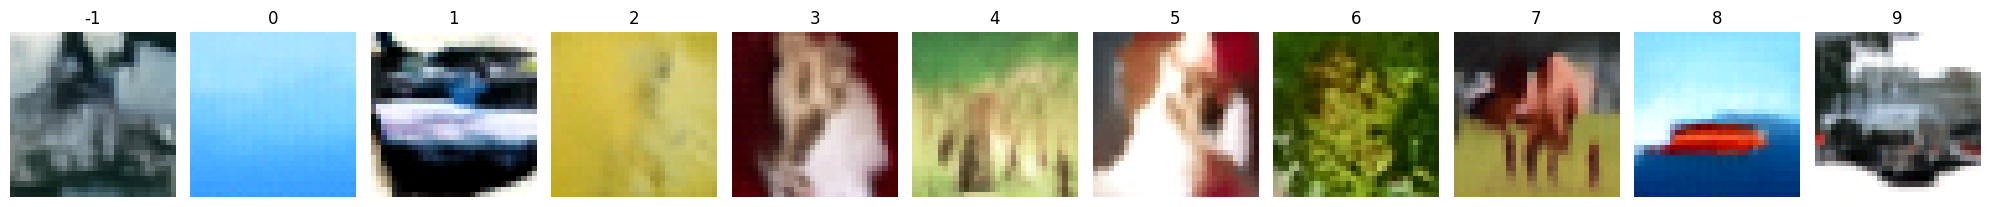

Epoch 44/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 32s 83ms/step - noise_loss: 0.0299 - val_image_loss: 0.0837 - val_loss: 0.0322 - val_noise_loss: 0.0322 - learning_rate: 3.5112e-05


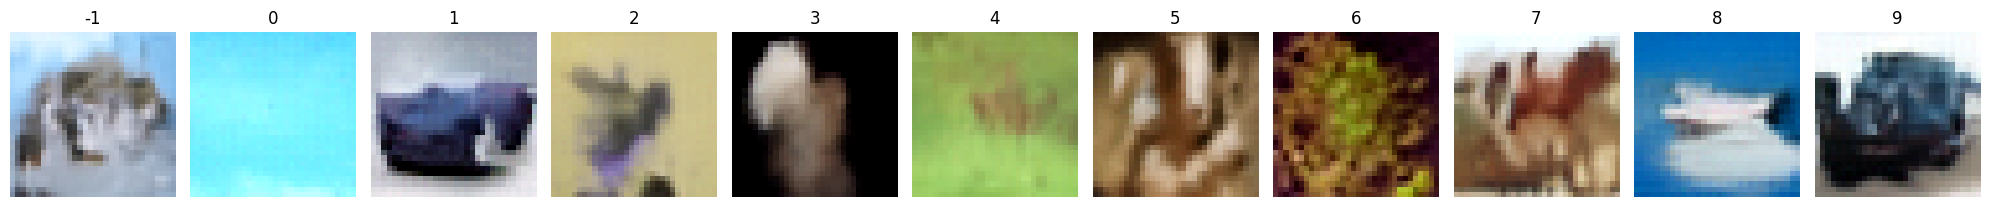

Epoch 45/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 34s 86ms/step - noise_loss: 0.0299 - val_image_loss: 0.0844 - val_loss: 0.0324 - val_noise_loss: 0.0324 - learning_rate: 2.4472e-05


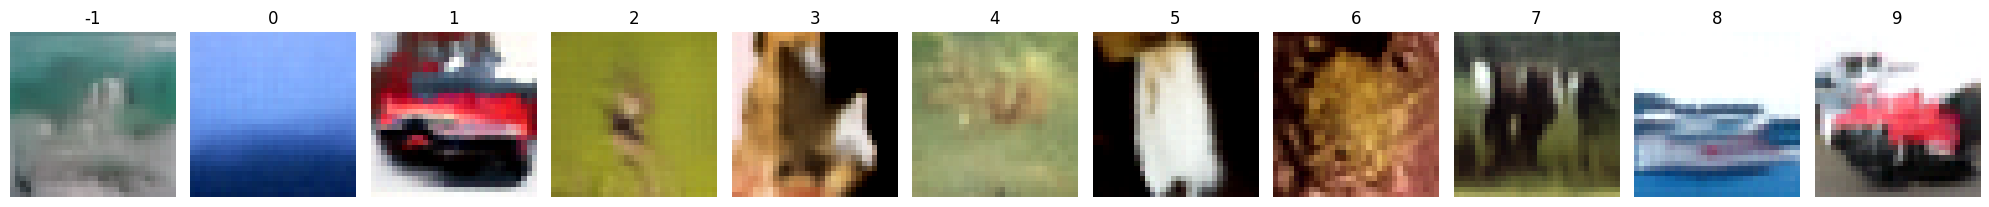

Epoch 46/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 33s 83ms/step - noise_loss: 0.0300 - val_image_loss: 0.0843 - val_loss: 0.0327 - val_noise_loss: 0.0327 - learning_rate: 1.5708e-05


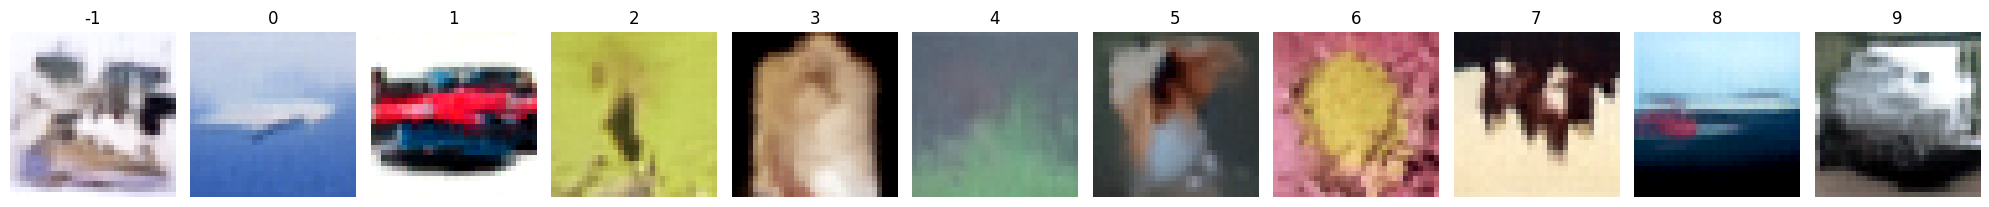

Epoch 47/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 33s 83ms/step - noise_loss: 0.0300 - val_image_loss: 0.0844 - val_loss: 0.0321 - val_noise_loss: 0.0321 - learning_rate: 8.8564e-06


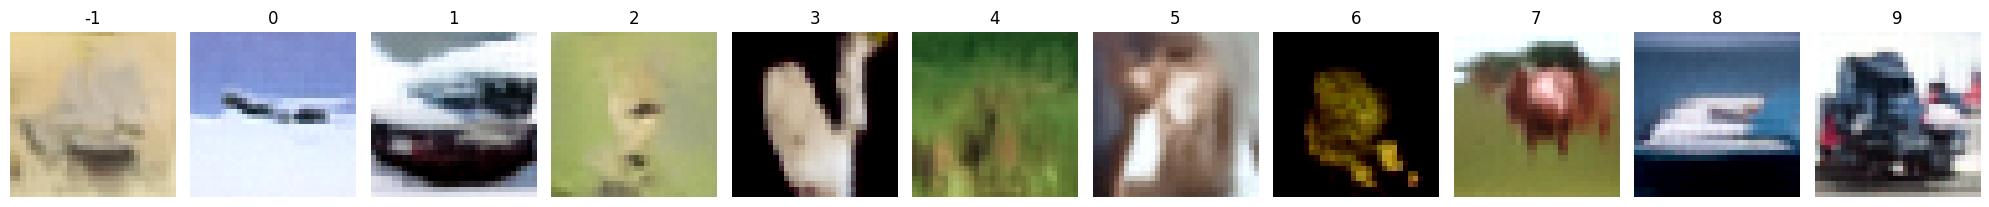

Epoch 48/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 33s 84ms/step - noise_loss: 0.0301 - val_image_loss: 0.0825 - val_loss: 0.0325 - val_noise_loss: 0.0325 - learning_rate: 3.9426e-06


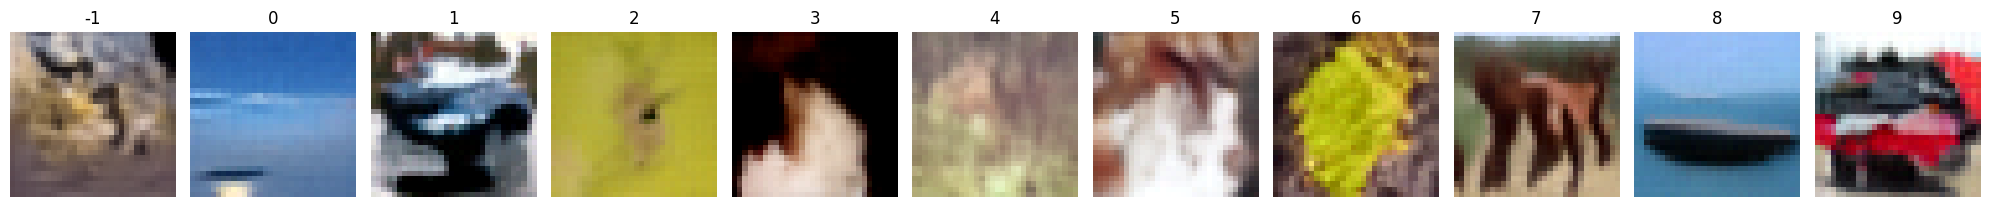

Epoch 49/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 34s 86ms/step - noise_loss: 0.0297 - val_image_loss: 0.0837 - val_loss: 0.0324 - val_noise_loss: 0.0324 - learning_rate: 9.8664e-07


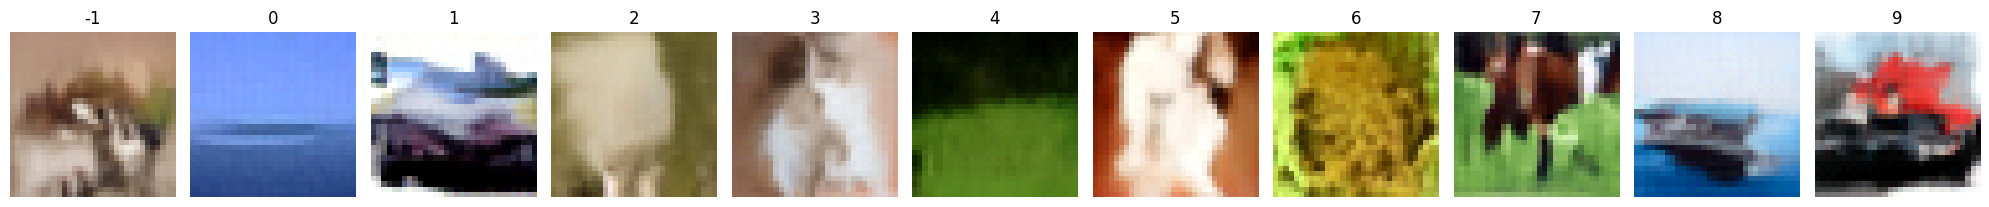

Epoch 50/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 33s 85ms/step - noise_loss: 0.0297 - val_image_loss: 0.0844 - val_loss: 0.0326 - val_noise_loss: 0.0326 - learning_rate: 0.0000e+00


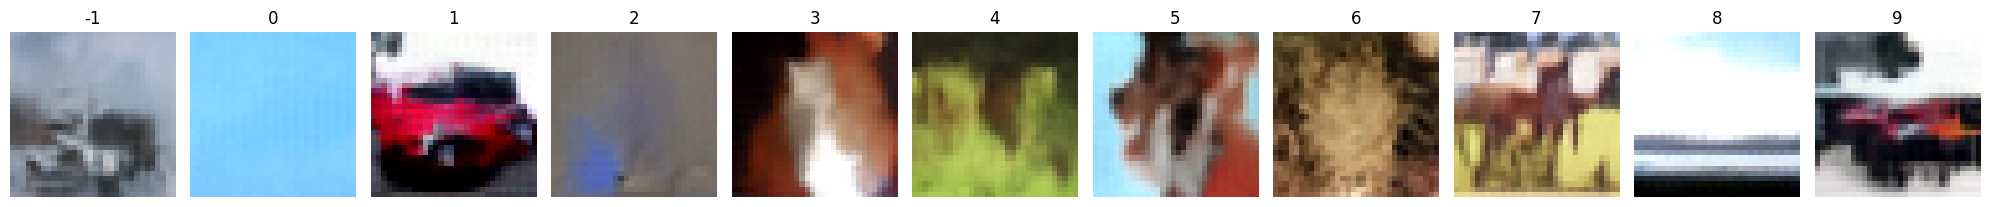

In [9]:
history = model.fit(
    trainset, 
    epochs=epochs, 
    validation_data=valset, 
    callbacks=callbacks_list
).history

In [10]:
model.save_weights("./models/CIFAR10 DiT mini/model.weights.h5")

In [11]:
model.evaluate(valset, network_name="ema")

79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - image_loss: 0.0821 - loss: 0.0327 - noise_loss: 0.0327


[<tf.Tensor: shape=(), dtype=float32, numpy=0.032684631645679474>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.032684631645679474>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.08207488059997559>]

In [12]:
model.evaluate(valset, network_name="raw")

79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 101ms/step - image_loss: 0.0833 - loss: 0.0327 - noise_loss: 0.0327


[<tf.Tensor: shape=(), dtype=float32, numpy=0.03272116929292679>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.03272116929292679>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.08327066153287888>]

Steps: 1000/1000


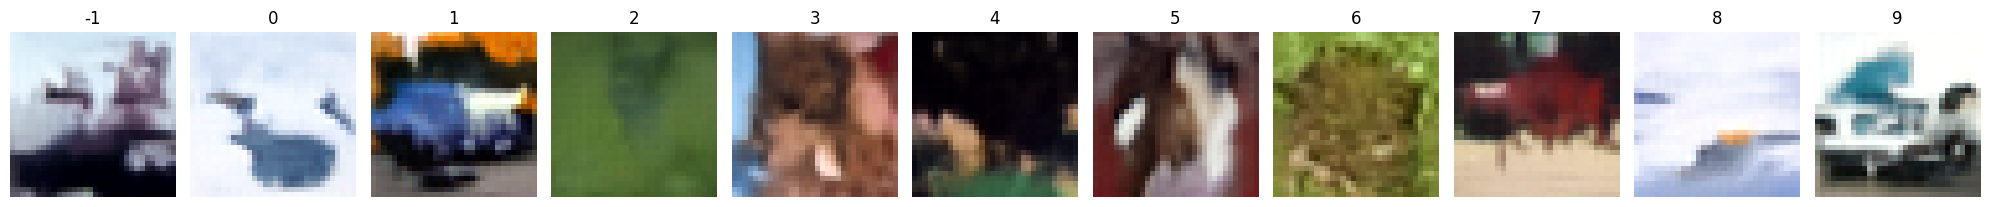

In [13]:
from common.utils import plot_images


imgs = model.sample(add_null_label=True, scale=3., eta=1., steps=1_000, verbose=True)
plot_images(imgs, has_null_label=True)

Steps: 1000/1000


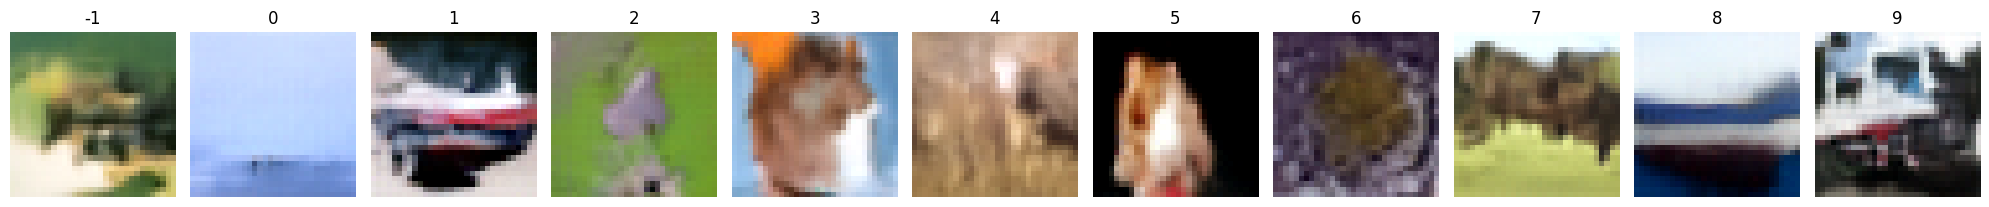

In [14]:
imgs = model.sample(add_null_label=True, scale=3., steps=1_000, verbose=True)
plot_images(imgs, has_null_label=True)

Steps: 50/50


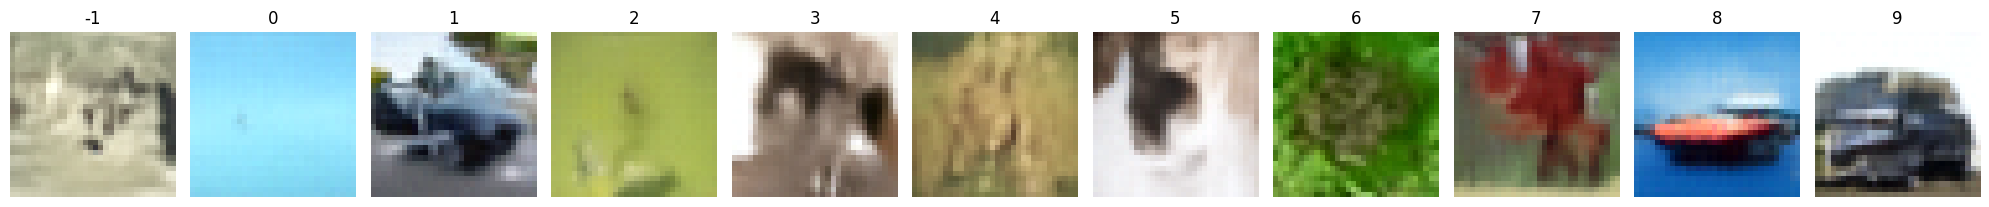

In [15]:
imgs = model.sample(add_null_label=True, scale=3., verbose=True)
plot_images(imgs, has_null_label=True)

Steps: 50/50


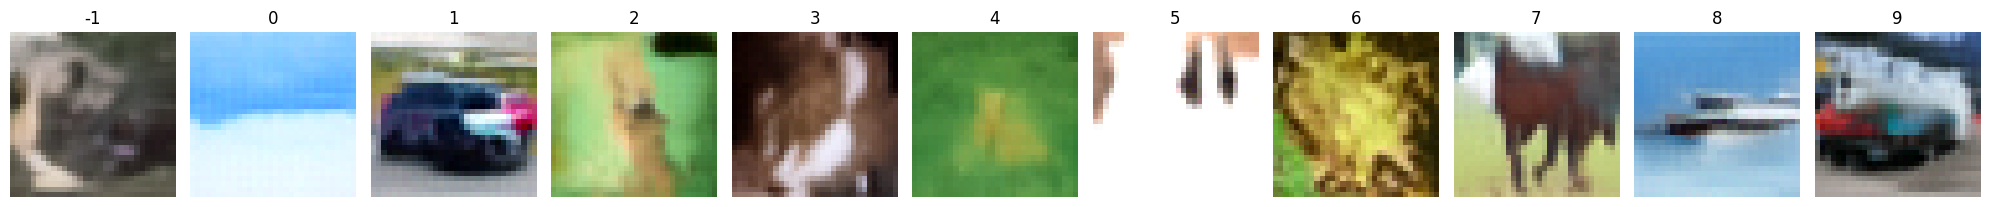

In [16]:
imgs = model.sample(add_null_label=True, scale=4., verbose=True)
plot_images(imgs, has_null_label=True)

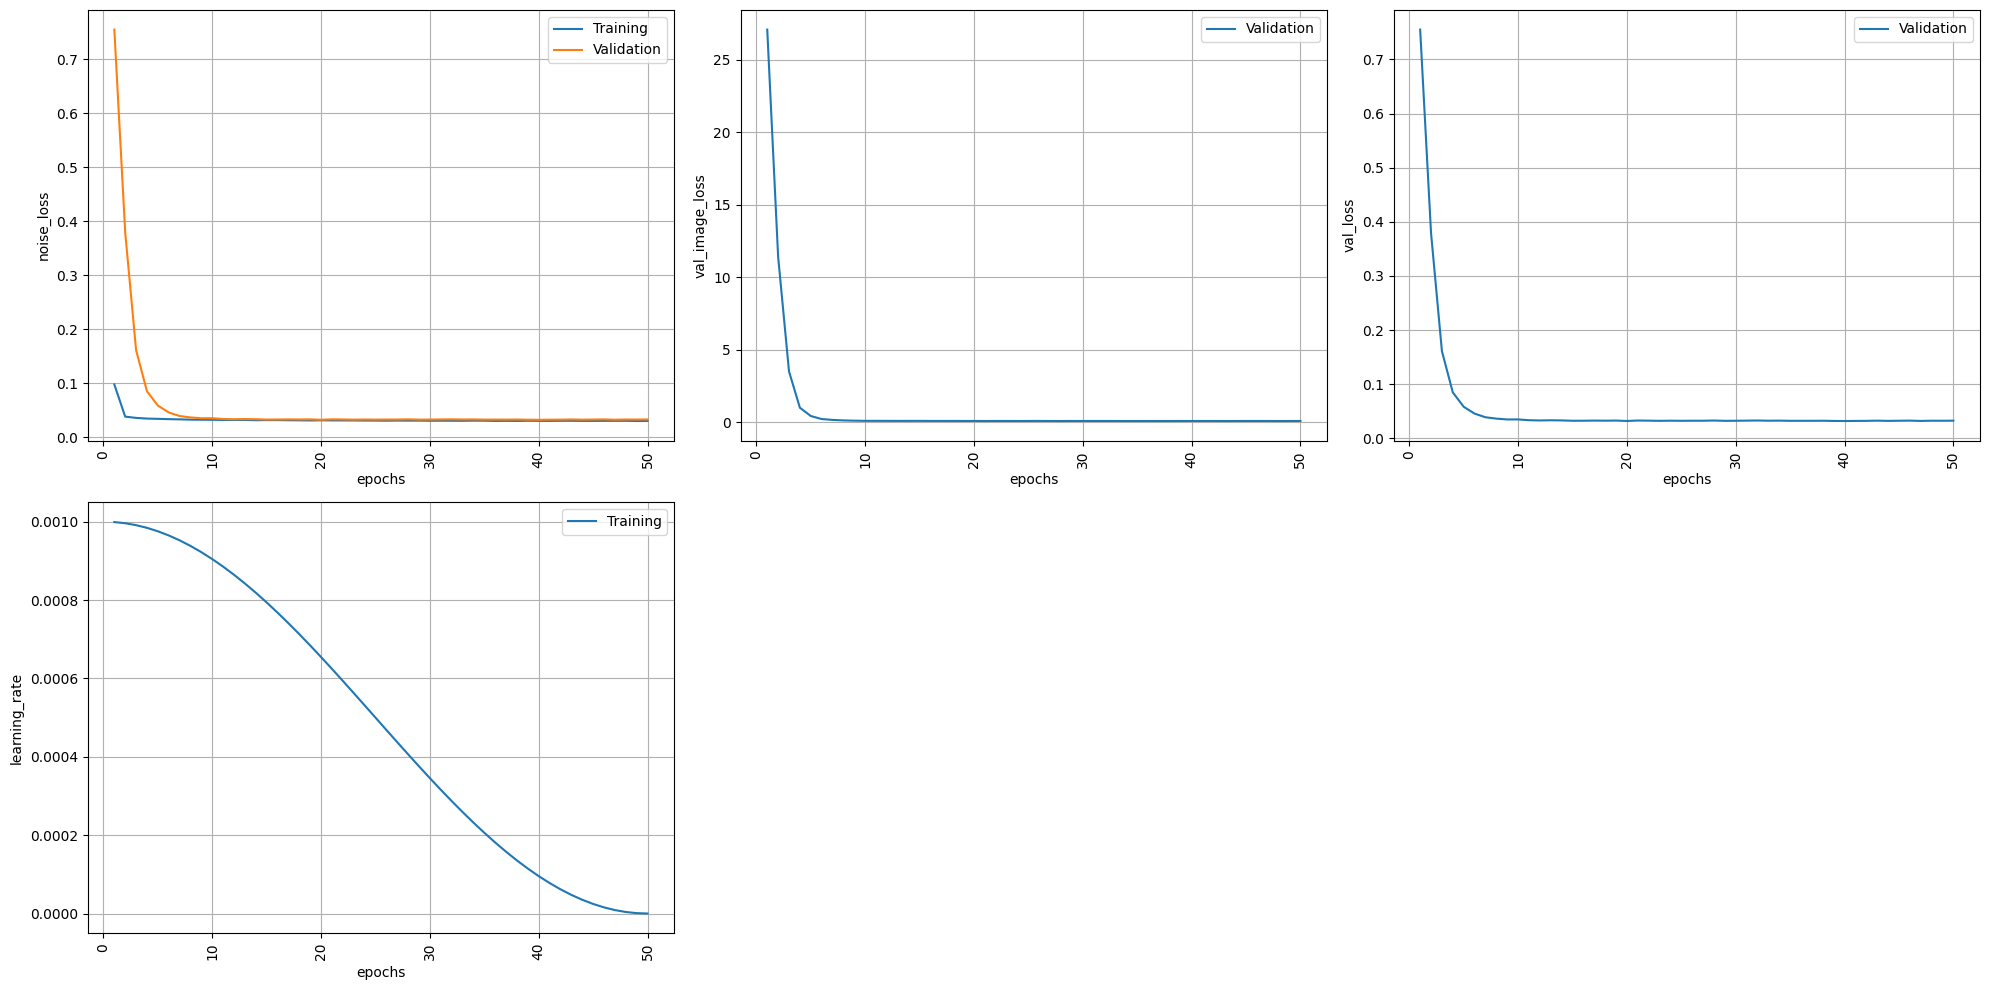

In [17]:
from common.utils import plot_history


plot_history(history, show_all_x_ticks=False)

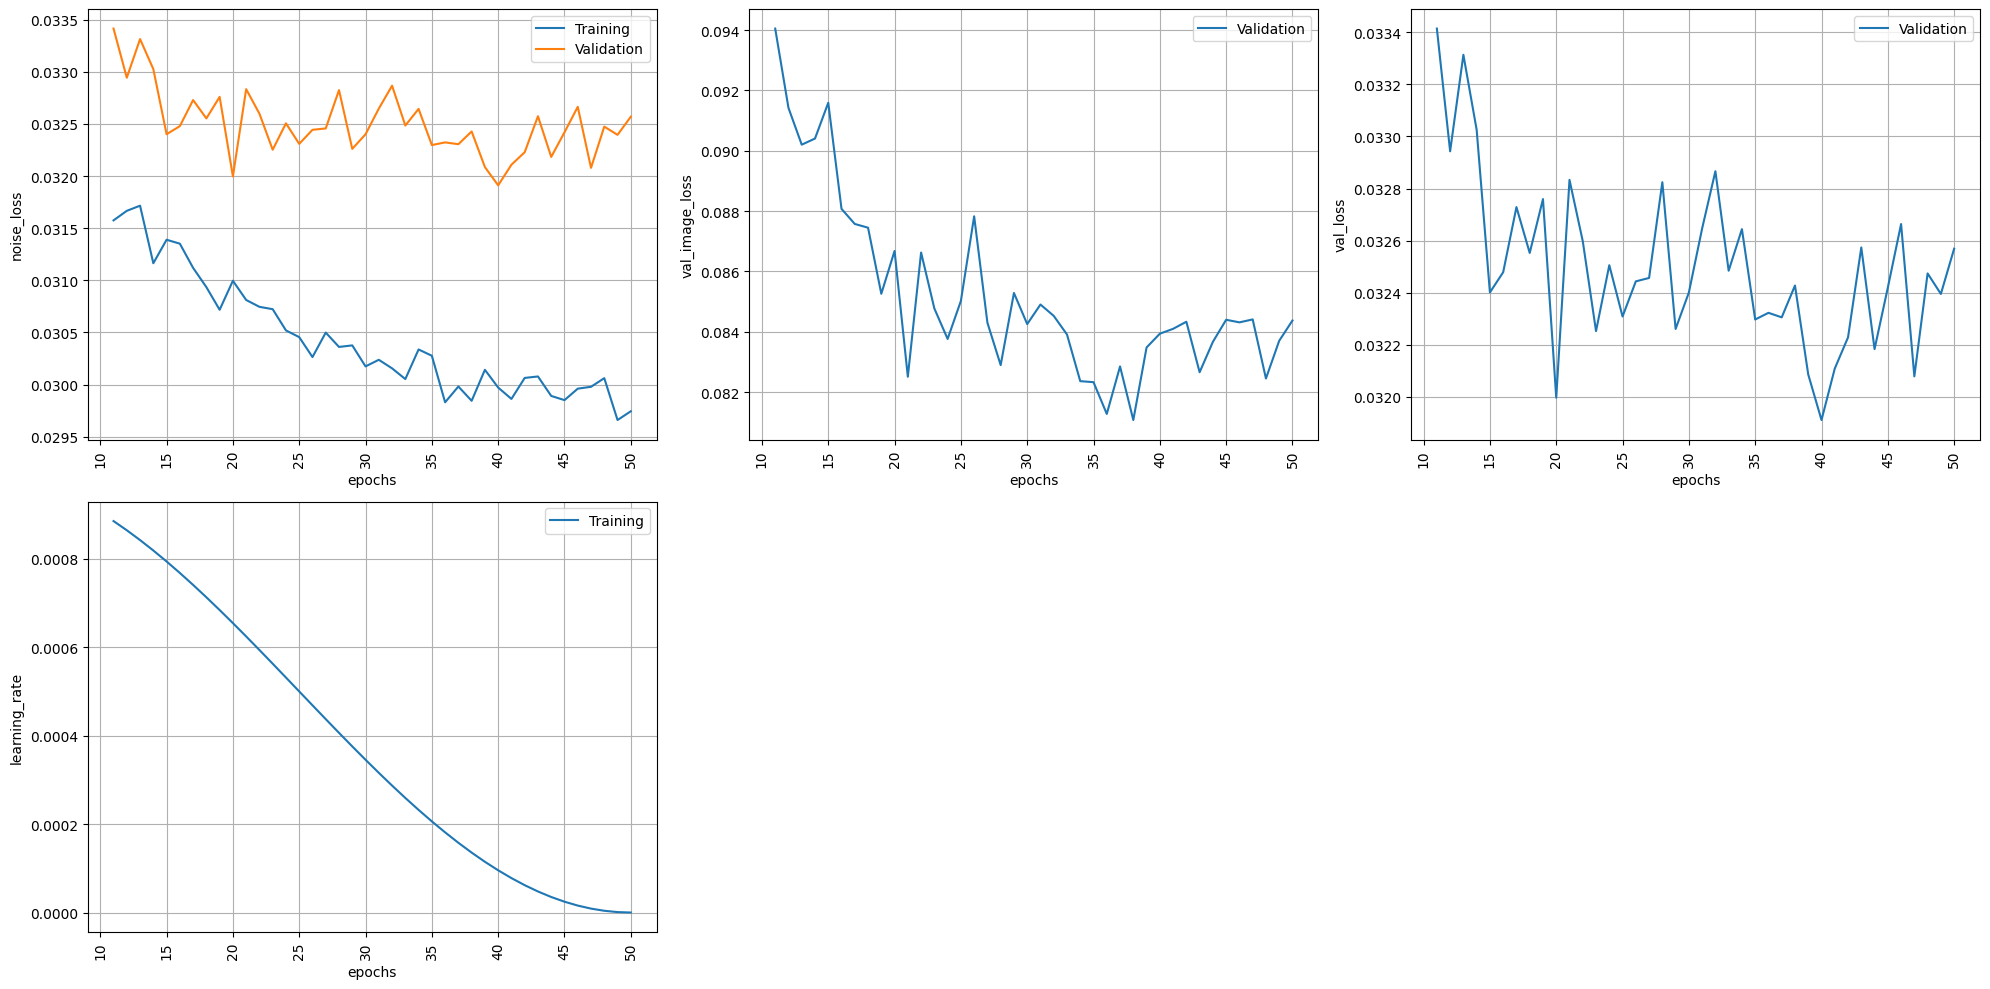

In [18]:
plot_history(history, show_all_x_ticks=False, range_=(10, None))